# Physics + AI Notebook: Programmer-Light +C Receiver

**Project idea:** verify optical phase recovery without needing a hidden true phase.

This notebook is intentionally **programmer-light**: it uses simple Python/PyTorch cells, clear comments, and physics checks.

## What +C means here

`+C` = **constraints**.

Instead of asking the AI to memorize the hidden phase, we ask whether the recovered complex field satisfies physical constraints:

- measured input intensity $I_1$
- measured output intensity $I_2$
- dispersion propagation model
- energy consistency
- phase / group-delay smoothness
- restart stability

## Research claim

> A recovered phase is credible when the complex field reproduces measured intensities and passes physics-based verification, even when the true phase is unavailable.


device = cpu
scalar shape: torch.Size([])
vector shape: torch.Size([2048])
matrix shape: torch.Size([8, 2048])
tensor shape: torch.Size([4, 2, 2048])


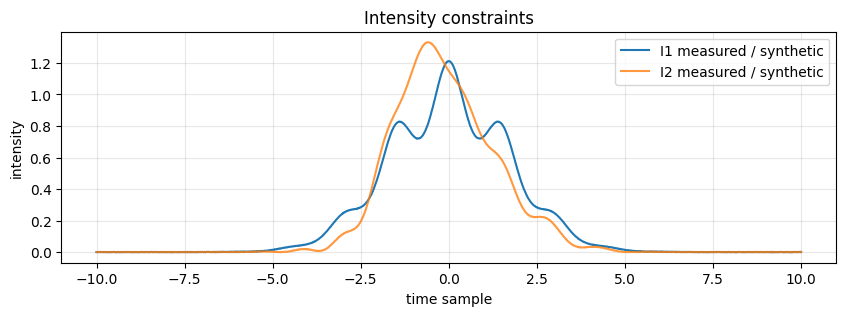

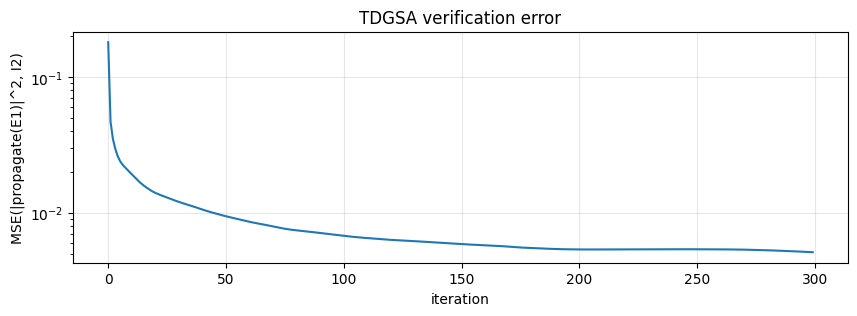

final total loss: 0.005091146100312471
final intensity loss: 0.0012039494467899203


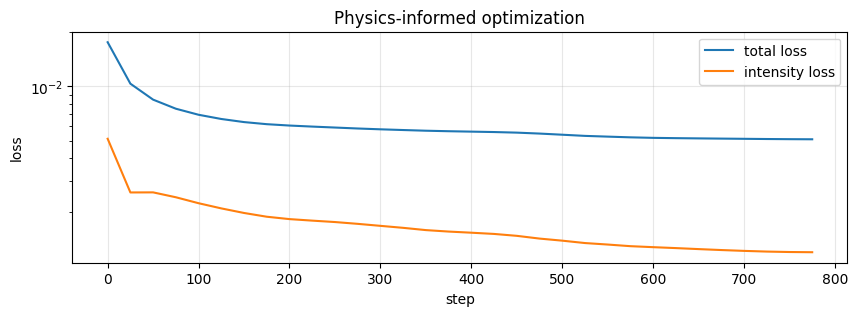

Physics verification features:
  intensity_mse                1.202172e-03
  1_minus_intensity_corr       3.072858e-03
  energy_error                 6.940802e-08
  phase_smoothness             2.305505e+00
  group_delay_smoothness       5.460492e+00
  tdgsa_final_error            5.136052e-03
  final_pinn_loss              5.091146e-03
UNSUPERVISED VERIFICATION: CHECK / NOT PASS
Verifier model exists. Train it later on many traces/restarts.


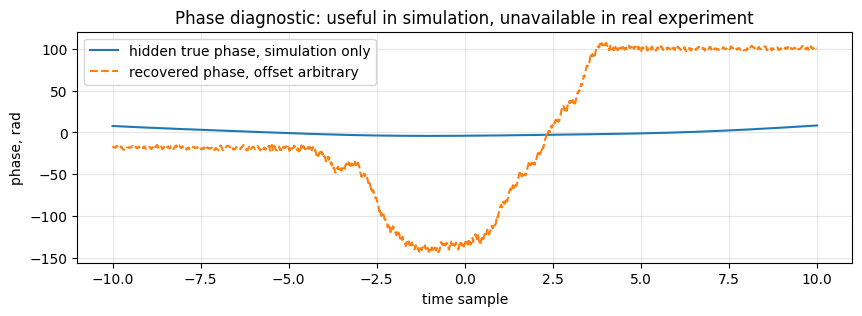

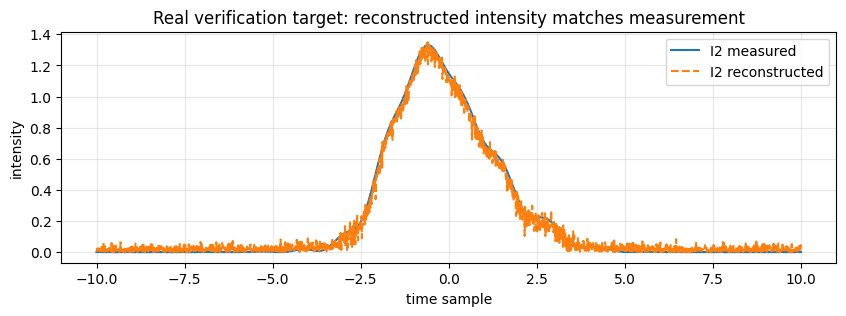


REAL MEASUREMENT PLAN

1. Split the optical pulse into two paths.
2. Path A: measure input/low-dispersion intensity I1 with photodiode + oscilloscope.
3. Path B: send through known dispersive element, then measure I2.
4. Record sampling rate, time step, fiber length, dispersion D or beta2, wavelength band.
5. Normalize traces: subtract dark offset, clip negatives, divide by total energy or max.
6. Resample I1 and I2 onto the same number of points.
7. Replace synthetic I1_meas and I2_meas in this notebook with real torch tensors.
8. Run TDGSA, then physics-informed refinement.
9. Judge success using intensity consistency, energy consistency, restart stability, and noise robustness.

Do not claim exact phase truth unless you have an independent phase measurement.



In [5]:
# ============================================================
# Physics + AI: one-notebook prototype for phase recovery checks
# Programmer-light +C version
# ============================================================

import math
import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
except Exception as e:
    raise RuntimeError("Install PyTorch first: pip install torch") from e

# -----------------------------
# 1. Device and reproducibility
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(7)
np.random.seed(7)
print("device =", device)

# -----------------------------
# 2. Scalar, vector, matrix, tensor semantics
# -----------------------------
scalar = torch.tensor(3.14, device=device)
vector = torch.linspace(-10, 10, 2048, device=device)
matrix = torch.randn(8, 2048, device=device)       # 8 traces
tensor = torch.randn(4, 2, 2048, device=device)    # batch x channel x samples

print("scalar shape:", scalar.shape)
print("vector shape:", vector.shape)
print("matrix shape:", matrix.shape)
print("tensor shape:", tensor.shape)

# -----------------------------
# 3. Synthetic measurement generator
# -----------------------------
# In a real experiment, replace I1_meas and I2_meas with oscilloscope traces.
# I1 = intensity before dispersion
# I2 = intensity after dispersion

N = 2048
t = torch.linspace(-10, 10, N, device=device)
dt = float(t[1] - t[0])
freq = torch.fft.fftfreq(N, d=dt).to(device)
omega = 2 * math.pi * freq

beta2 = -0.85
L = 1.0
H = torch.exp(-0.5j * beta2 * L * omega**2)

# Hidden simulation only: real experiments do NOT give this phase.
amp_true = torch.exp(-0.5 * (t / 2.4)**2) * (1.0 + 0.10 * torch.cos(4.0 * t))
amp_true = torch.clamp(amp_true, min=0.0)
phi_true = 0.12 * t**2 + 0.45 * torch.sin(0.7 * t)
E1_true = amp_true * torch.exp(1j * phi_true)
E2_true = torch.fft.ifft(torch.fft.fft(E1_true) * H)

noise = 0.002
I1_meas = torch.abs(E1_true)**2 + noise * torch.rand(N, device=device)
I2_meas = torch.abs(E2_true)**2 + noise * torch.rand(N, device=device)
I1_meas = torch.clamp(I1_meas, min=0.0)
I2_meas = torch.clamp(I2_meas, min=0.0)

plt.figure(figsize=(10, 3))
plt.plot(t.detach().cpu(), I1_meas.detach().cpu(), label="I1 measured / synthetic")
plt.plot(t.detach().cpu(), I2_meas.detach().cpu(), label="I2 measured / synthetic", alpha=0.8)
plt.title("Intensity constraints")
plt.xlabel("time sample")
plt.ylabel("intensity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 4. TDGSA-style alternating projection baseline
# -----------------------------
def tdgsa(I1, I2, H, n_iter=250, seed=0):
    """Simple time-domain Gerchberg-Saxton loop using two intensity constraints."""
    torch.manual_seed(seed)
    phase = 2 * math.pi * torch.rand_like(I1) - math.pi
    E1 = torch.sqrt(I1 + 1e-12) * torch.exp(1j * phase)
    errors = []
    for k in range(n_iter):
        E2 = torch.fft.ifft(torch.fft.fft(E1) * H)
        I2_pred = torch.abs(E2)**2
        errors.append(torch.mean((I2_pred - I2)**2).detach())
        E2 = torch.sqrt(I2 + 1e-12) * torch.exp(1j * torch.angle(E2))
        E1_back = torch.fft.ifft(torch.fft.fft(E2) * torch.conj(H))
        E1 = torch.sqrt(I1 + 1e-12) * torch.exp(1j * torch.angle(E1_back))
    return E1, torch.stack(errors)

E1_gs, gs_errors = tdgsa(I1_meas, I2_meas, H, n_iter=300, seed=2)

plt.figure(figsize=(10, 3))
plt.semilogy(gs_errors.detach().cpu())
plt.title("TDGSA verification error")
plt.xlabel("iteration")
plt.ylabel("MSE(|propagate(E1)|^2, I2)")
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# 5. Physics-informed Torch refinement
# -----------------------------
phase = torch.nn.Parameter(torch.angle(E1_gs).detach().clone())
optimizer = torch.optim.Adam([phase], lr=0.025)

loss_history = []
for step in range(800):
    E1 = torch.sqrt(I1_meas + 1e-12) * torch.exp(1j * phase)
    E2 = torch.fft.ifft(torch.fft.fft(E1) * H)
    I2_pred = torch.abs(E2)**2

    intensity_loss = torch.mean((I2_pred - I2_meas)**2)
    energy_loss = (torch.sum(torch.abs(E1)**2) - torch.sum(torch.abs(E2)**2)).pow(2) / (N**2)
    phase_smooth_loss = torch.mean((phase[1:] - phase[:-1])**2)
    group_delay_smooth_loss = torch.mean((phase[2:] - 2*phase[1:-1] + phase[:-2])**2)

    loss = intensity_loss + 0.001 * energy_loss + 0.0005 * phase_smooth_loss + 0.0005 * group_delay_smooth_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 25 == 0:
        loss_history.append([step, float(loss.detach()), float(intensity_loss.detach()), float(phase_smooth_loss.detach())])

loss_history = np.array(loss_history)
print("final total loss:", loss_history[-1,1])
print("final intensity loss:", loss_history[-1,2])

plt.figure(figsize=(10, 3))
plt.semilogy(loss_history[:,0], loss_history[:,1], label="total loss")
plt.semilogy(loss_history[:,0], loss_history[:,2], label="intensity loss")
plt.title("Physics-informed optimization")
plt.xlabel("step")
plt.ylabel("loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 6. Verification metrics beyond hidden phase RMSE
# -----------------------------
with torch.no_grad():
    E1_rec = torch.sqrt(I1_meas + 1e-12) * torch.exp(1j * phase)
    E2_rec = torch.fft.ifft(torch.fft.fft(E1_rec) * H)
    I2_rec = torch.abs(E2_rec)**2

    intensity_mse = torch.mean((I2_rec - I2_meas)**2)
    intensity_corr = torch.corrcoef(torch.stack([I2_rec, I2_meas]))[0,1]
    energy_error = torch.abs(torch.sum(torch.abs(E1_rec)**2) - torch.sum(torch.abs(E2_rec)**2)) / torch.sum(torch.abs(E1_rec)**2)
    phase_smoothness = torch.mean((phase[1:] - phase[:-1])**2)
    group_delay_smoothness = torch.mean((phase[2:] - 2*phase[1:-1] + phase[:-2])**2)

features = torch.tensor([
    float(intensity_mse),
    float(1 - intensity_corr),
    float(energy_error),
    float(phase_smoothness),
    float(group_delay_smoothness),
    float(gs_errors[-1]),
    float(loss_history[-1,1]),
])

names = [
    "intensity_mse",
    "1_minus_intensity_corr",
    "energy_error",
    "phase_smoothness",
    "group_delay_smoothness",
    "tdgsa_final_error",
    "final_pinn_loss",
]

print("Physics verification features:")
for n, v in zip(names, features):
    print(f"  {n:28s} {float(v):.6e}")

passed = (
    intensity_mse < 5e-4 and
    intensity_corr > 0.98 and
    energy_error < 1e-5 and
    phase_smoothness < 2.0
)
print("UNSUPERVISED VERIFICATION:", "PASS" if passed else "CHECK / NOT PASS")

# -----------------------------
# 7. Optional classifier scaffold
# -----------------------------
class PhaseVerifier(torch.nn.Module):
    def __init__(self, n_features=7):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(n_features, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 8),
            torch.nn.ReLU(),
            torch.nn.Linear(8, 1),
        )
    def forward(self, x):
        return self.net(x)

verifier = PhaseVerifier(n_features=len(features)).to(device)
print("Verifier model exists. Train it later on many traces/restarts.")

# -----------------------------
# 8. Plots: phase comparison is diagnostic, not final truth
# -----------------------------
import numpy as np

phase_rec_cpu = np.unwrap(phase.detach().cpu().numpy())
phase_true_cpu = np.unwrap(phi_true.detach().cpu().numpy())

# Remove arbitrary global phase
phase_rec_aligned = phase_rec_cpu - np.mean(phase_rec_cpu)
phase_true_aligned = phase_true_cpu - np.mean(phase_true_cpu)
(phase_true_cpu)

plt.figure(figsize=(10, 3))
plt.plot(t.detach().cpu(), phase_true_aligned, label="hidden true phase, simulation only")
plt.plot(t.detach().cpu(), phase_rec_aligned, "--", label="recovered phase, offset arbitrary")
plt.title("Phase diagnostic: useful in simulation, unavailable in real experiment")
plt.xlabel("time sample")
plt.ylabel("phase, rad")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(t.detach().cpu(), I2_meas.detach().cpu(), label="I2 measured")
plt.plot(t.detach().cpu(), I2_rec.detach().cpu(), "--", label="I2 reconstructed")
plt.title("Real verification target: reconstructed intensity matches measurement")
plt.xlabel("time sample")
plt.ylabel("intensity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 9. How to take real measurements
# -----------------------------
measurement_instructions = """
REAL MEASUREMENT PLAN

1. Split the optical pulse into two paths.
2. Path A: measure input/low-dispersion intensity I1 with photodiode + oscilloscope.
3. Path B: send through known dispersive element, then measure I2.
4. Record sampling rate, time step, fiber length, dispersion D or beta2, wavelength band.
5. Normalize traces: subtract dark offset, clip negatives, divide by total energy or max.
6. Resample I1 and I2 onto the same number of points.
7. Replace synthetic I1_meas and I2_meas in this notebook with real torch tensors.
8. Run TDGSA, then physics-informed refinement.
9. Judge success using intensity consistency, energy consistency, restart stability, and noise robustness.

Do not claim exact phase truth unless you have an independent phase measurement.
"""
print(measurement_instructions)


## Notes for the report

- **Syntax**: the Python/Torch commands.
- **Semantics**: the physics meaning of the commands.
- **Operators**: FFT, multiplication, exponentiation, loss, gradient descent.
- **Operands**: scalars, vectors, matrices, tensors, complex fields.

### Main claim

The notebook does not prove that the hidden phase is uniquely recovered. It verifies that a recovered complex field is physically consistent with the measured intensity constraints and the dispersion model.

### Why this matters

In real optical experiments, the true phase is usually unavailable. Therefore, the practical engineering problem is not “did we match the hidden phase?” but “does the recovered field explain the measurements and survive verification?”
